In [15]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from  mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import urllib.request

In [9]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"

with open('apriori.csv', 'wb') as f:
    response = urllib.request.urlopen(url)
    f.write(response.read().decode('utf-8').encode('utf-8'))
    
data = []
with open('apriori.csv', 'r') as f2:
    for i in f2:
        data.append(i.strip().split(','))

In [10]:
te = TransactionEncoder()
te_ary = te.fit(data).transform(data)
df = pd.DataFrame(te_ary, columns=te.columns_)
df.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [14]:
frequent_itemsets = apriori(df, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.5)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(other vegetables),0.052466,0.193493,0.019725,0.375969,1.943066,1.0,0.009574,1.292416,0.512224,0.087191,0.226255,0.238957
1,(other vegetables),(beef),0.193493,0.052466,0.019725,0.101944,1.943066,1.0,0.009574,1.055095,0.601792,0.087191,0.052218,0.238957
2,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455
3,(root vegetables),(beef),0.108998,0.052466,0.017387,0.159515,3.040367,1.0,0.011668,1.127366,0.753189,0.120677,0.112977,0.245455
4,(whole milk),(beef),0.255516,0.052466,0.021251,0.083168,1.585180,1.0,0.007845,1.033487,0.495856,0.074113,0.032402,0.244103


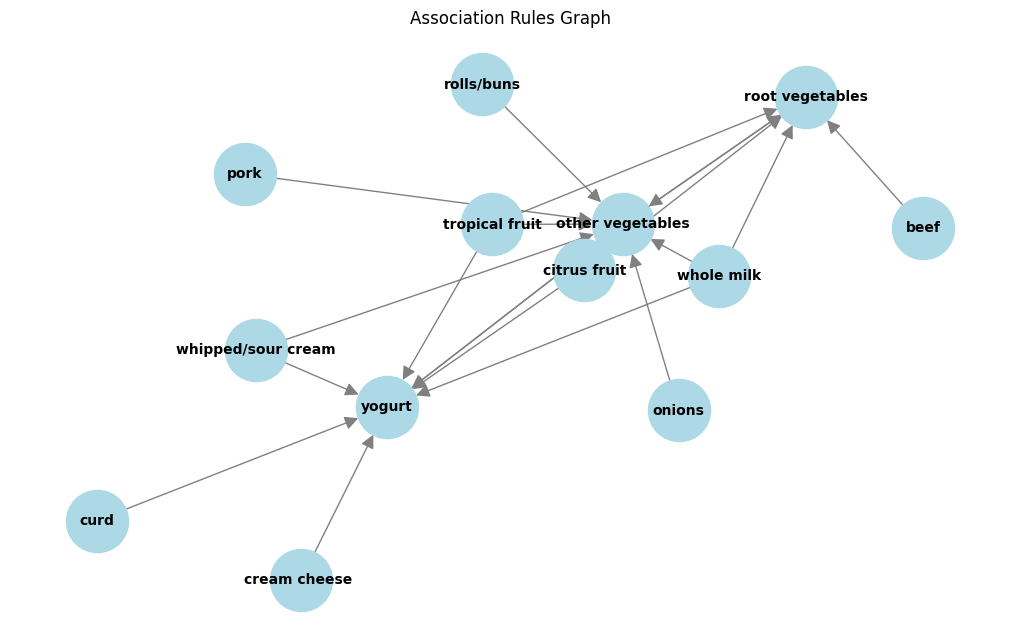

In [25]:
plt.figure(figsize=(10, 6))
strong_rules = rules[rules['confidence'] > 0.3].nlargest(20, 'lift')

G = nx.DiGraph()
for _, row in strong_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])
            
p = nx.spring_layout(G, k=0.5)
nx.draw(G, p, with_labels=True, node_size=2000, node_color='lightblue', font_size=10,arrowsize=20, font_weight='bold', edge_color='gray')
plt.title('Association Rules Graph')
plt.show()

In [29]:
strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
224,"(citrus fruit, other vegetables)",(root vegetables),0.028876,0.108998,0.010371,0.359155,3.295045,1.0,0.007224,1.390354,0.717225,0.081340,0.280759,0.227152
290,"(tropical fruit, other vegetables)",(root vegetables),0.035892,0.108998,0.012303,0.342776,3.144780,1.0,0.008391,1.355705,0.707403,0.092791,0.262376,0.227825
2,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455
222,"(root vegetables, citrus fruit)",(other vegetables),0.017692,0.193493,0.010371,0.586207,3.029608,1.0,0.006948,1.949059,0.681990,0.051646,0.486932,0.319903
288,"(root vegetables, tropical fruit)",(other vegetables),0.021047,0.193493,0.012303,0.584541,3.020999,1.0,0.008231,1.941244,0.683367,0.060835,0.484867,0.324062
295,"(whole milk, other vegetables)",(root vegetables),0.074835,0.108998,0.023183,0.309783,2.842082,1.0,0.015026,1.290900,0.700572,0.144304,0.225347,0.261235
241,"(whole milk, curd)",(yogurt),0.026131,0.139502,0.010066,0.385214,2.761356,1.0,0.006421,1.399671,0.654974,0.064706,0.285546,0.228686
276,"(rolls/buns, root vegetables)",(other vegetables),0.024301,0.193493,0.012201,0.502092,2.594890,1.0,0.007499,1.619792,0.629935,0.059347,0.382637,0.282575
300,"(yogurt, root vegetables)",(other vegetables),0.025826,0.193493,0.012913,0.500000,2.584078,1.0,0.007916,1.613015,0.629266,0.062562,0.380043,0.283368
371,"(whole milk, tropical fruit)",(yogurt),0.042298,0.139502,0.015150,0.358173,2.567516,1.0,0.009249,1.340701,0.637483,0.090909,0.254122,0.233387
